# 1. Import & Load Data

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [120]:
df = pd.read_csv('winequality-white.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


# 2. EDA

In [121]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None


In [122]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    4898.000000       4898.000000  4898.000000     4898.000000   
mean        6.854788          0.278241     0.334192        6.391415   
std         0.843868          0.100795     0.121020        5.072058   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.700000   
50%         6.800000          0.260000     0.320000        5.200000   
75%         7.300000          0.320000     0.390000        9.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  4898.000000          4898.000000           4898.000000  4898.000000   
mean      0.045772            35.308085            138.360657     0.994027   
std       0.021848            17.007137             42.498065     0.002991   
min       0.009000             2.000000         

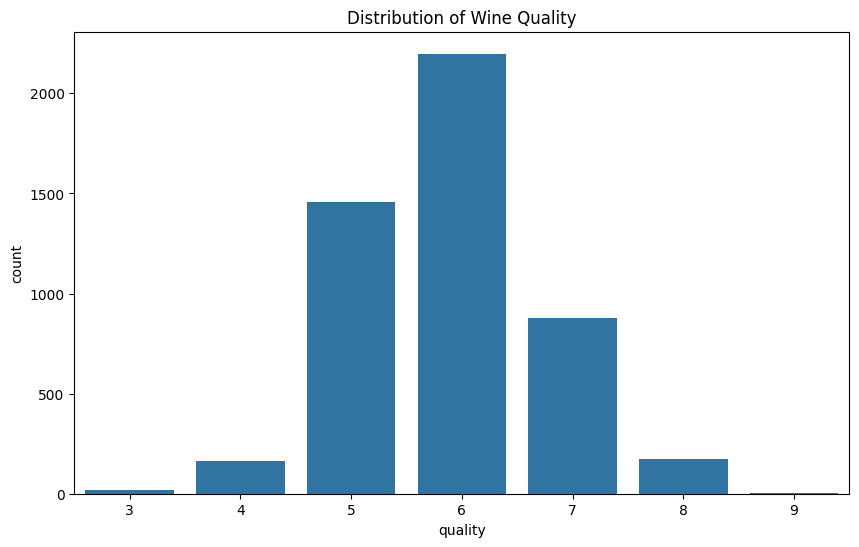

In [123]:
plt.figure(figsize=(10,6))
sns.countplot(x='quality', data=df)
plt.title("Distribution of Wine Quality")
plt.show()

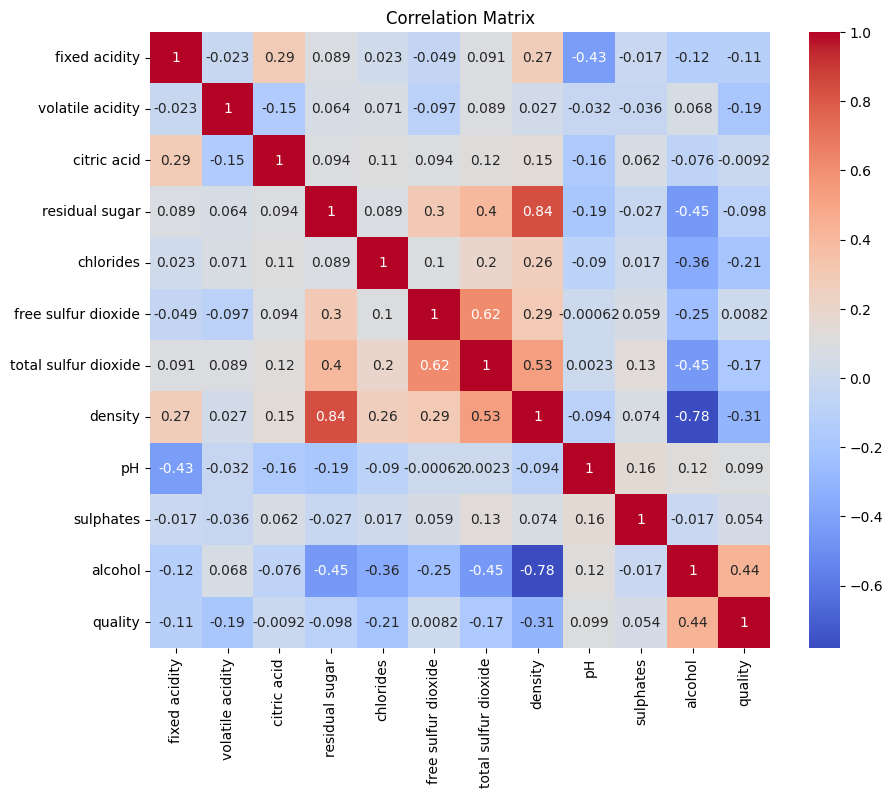

In [124]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Matrix")
plt.show()

# 3. Feature Selection

In [126]:
corr = df.corr()['quality'].abs().sort_values(ascending=False)
print(corr)

quality                 1.000000
alcohol                 0.462869
density                 0.337805
chlorides               0.217739
volatile acidity        0.190678
total sulfur dioxide    0.183356
fixed acidity           0.124636
pH                      0.123829
residual sugar          0.117339
sulphates               0.053200
free sulfur dioxide     0.010507
citric acid             0.007065
Name: quality, dtype: float64


In [127]:
low_corr = corr[corr < 0.05].index.tolist()

if 'quality' in low_corr:
    low_corr.remove('quality')

df = df.drop(columns=low_corr)

# 4. Convert Target

In [128]:
# Binary classification
df['quality'] = (df['quality'] >= 6).astype(int)

# 5. Train Test Split

In [129]:
X = df.drop(columns='quality').to_numpy()
y = df['quality'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Assignment 1:
- Implementing Decision Tree using NumPy.
- Train and evaluate this method on the [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) dataset using F1 score.

In [130]:
class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

        self.tree = None

    def gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        prob = counts / counts.sum()    
        return 1 - np.sum(prob ** 2)

    def split(self, X, y, feature, threshold):
        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold
        return X[left_idx], X[right_idx], y[left_idx], y[right_idx]    

    def best_split(self, X, y):
        best_gini = float("inf")
        best_feature = None
        best_threshold = None

        n_samples, n_feature = X.shape

        for feature in range(n_feature):
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)

                if len(X_left) == 0 or len(X_right) == 0:
                    continue

                gini_left = self.gini(y_left) 
                gini_right = self.gini(y_right)

                weight_gini = (len(y_left) * gini_left + len(y_right) * gini_right) / len(y)

                if weight_gini < best_gini:
                    best_gini = weight_gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth):
        if len(np.unique(y)) == 1:
            return y[0]
        
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return self.majority_class(y)
        
        feature, threshold = self.best_split(X, y)

        if feature is None:
            return self.majority_class(y)
        
        X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)
        
        left = self.build_tree(X_left, y_left, depth + 1)
        right = self.build_tree(X_right, y_right, depth + 1)

        return {
            "feature": feature,
            "threshold": threshold,
            "left": left,
            "right": right 
        }
        
    def majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def fit(self, X, y):
        self.tree = self.build_tree(X, y, 0)

    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node

        if x[node["feature"]] <= node["threshold"]:
            return self.predict_one(x, node["left"])
        else:
            return self.predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])

In [131]:
decision_tree = DecisionTree(max_depth=10, min_samples_split=2)
decision_tree.fit(X_train, y_train)

In [132]:
y_predict = decision_tree.predict(X_test)

f1 = f1_score(y_test, y_predict, average='micro')

print(f1)

0.694829760403531


## Assignment 2:
- Implementing Random Forest using NumPy.
- Train and evaluate this method on the [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) dataset using F1 score.

In [133]:
class RandomForest:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, max_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]

    def fit(self, X, y):
        self.trees = []
        n_features = X.shape[1]
        if self.max_features is None:
            self.max_features = int(np.sqrt(n_features))

        for _ in range(self.n_trees):
            tree = DecisionTreeRF(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            X_sample, y_sample = self.bootstrap_sample(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        # Collect predictions from each tree
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Majority vote for each sample
        final_preds = []
        for col in range(tree_preds.shape[1]):
            votes = tree_preds[:, col]
            values, counts = np.unique(votes, return_counts=True)
            final_preds.append(values[np.argmax(counts)])
        return np.array(final_preds)


class DecisionTreeRF:
    """Decision Tree with random feature selection for Random Forest"""
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.tree = None

    def gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        prob = counts / counts.sum()
        return 1 - np.sum(prob ** 2)

    def split(self, X, y, feature, threshold):
        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold
        return X[left_idx], X[right_idx], y[left_idx], y[right_idx]

    def best_split(self, X, y):
        best_gini = float('inf')
        best_feature = None
        best_threshold = None

        n_samples, n_features = X.shape
        # Randomly select a subset of features
        feature_indices = np.random.choice(n_features, size=self.max_features, replace=False)

        for feature in feature_indices:
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)
                if len(X_left) == 0 or len(X_right) == 0:
                    continue
                gini_left = self.gini(y_left)
                gini_right = self.gini(y_right)
                weight_gini = (len(y_left) * gini_left + len(y_right) * gini_right) / len(y)
                if weight_gini < best_gini:
                    best_gini = weight_gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def build_tree(self, X, y, depth):
        if len(np.unique(y)) == 1:
            return y[0]
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return self.majority_class(y)
        feature, threshold = self.best_split(X, y)
        if feature is None:
            return self.majority_class(y)
        X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)
        left = self.build_tree(X_left, y_left, depth + 1)
        right = self.build_tree(X_right, y_right, depth + 1)
        return {'feature': feature, 'threshold': threshold, 'left': left, 'right': right}

    def fit(self, X, y):
        self.tree = self.build_tree(X, y, 0)

    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])


In [134]:
random_forest = RandomForest(n_trees=10, max_depth=10, min_samples_split=2)
random_forest.fit(X_train, y_train)

y_predict_rf = random_forest.predict(X_test)

f1_rf = f1_score(y_test, y_predict_rf, average='micro')

print('Random Forest F1 Score (NumPy):', f1_rf)


Random Forest F1 Score (NumPy): 0.7313997477931904


## Assignment 3:
- Train and evaluate the Decision Tree method using a machine learning library.
- Train and evaluate the Random Forest method using a machine learning library.

In [135]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree with sklearn
dt_sklearn = DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=42)
dt_sklearn.fit(X_train, y_train)
y_pred_dt_sklearn = dt_sklearn.predict(X_test)
f1_dt_sklearn = f1_score(y_test, y_pred_dt_sklearn, average='micro')
print('Decision Tree F1 Score (sklearn):', f1_dt_sklearn)

# Random Forest with sklearn
rf_sklearn = RandomForestClassifier(n_estimators=10, max_depth=10, min_samples_split=2, random_state=42)
rf_sklearn.fit(X_train, y_train)
y_pred_rf_sklearn = rf_sklearn.predict(X_test)
f1_rf_sklearn = f1_score(y_test, y_pred_rf_sklearn, average='micro')
print('Random Forest F1 Score (sklearn):', f1_rf_sklearn)


Decision Tree F1 Score (sklearn): 0.6973518284993695
Random Forest F1 Score (sklearn): 0.7326607818411097
